<a href="https://colab.research.google.com/github/Rithanya-J/Stock_ML_Sentiment_Colab/blob/main/Stock_ML_Sentiment_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Stock Market Analysis with Supervised ML + Sentiment (Colab-ready)

This notebook gives you an end‑to‑end pipeline you can finish **today**:
1) Data download (Yahoo Finance)  
2) Technical indicators (ta)  
3) News sentiment (VADER via `yfinance.Ticker(...).news`)  
4) Feature merge and train/test split  
5) Train models: Linear Regression, Random Forest, SVR, XGBoost  
6) Evaluate (MAE, RMSE, MAPE, R²) + plots  
7) Next‑day prediction from the latest data

**Tip:** Run cells from top to bottom in order. If a library fails to install, run the cell again.


In [ ]:
# ✅ Setup (install libraries)
import sys
IN_COLAB = 'google.colab' in sys.modules
print('Running in Colab:', IN_COLAB)

!pip -q install yfinance ta xgboost nltk plotly scikit-learn --no-input
import nltk
nltk.download('vader_lexicon')
print('Setup complete')


Running in Colab: True
  Preparing metadata (setup.py) ... done
Setup complete


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


## 🔧 Inputs
Pick the ticker and date range. For Indian stocks on Yahoo, use the `.NS` suffix (e.g., `RELIANCE.NS`).


In [ ]:
from datetime import datetime

TICKER = 'RELIANCE.NS'
START  = '2018-01-01'
END    = datetime.today().strftime('%Y-%m-%d')

PREDICT_TARGET = 'Close' # 'Close' or 'Return_1d_ahead'
TEST_SIZE_DAYS = 365     # last N days for testing

print('Ticker:', TICKER, '| Range:', START, 'to', END)


Ticker: RELIANCE.NS | Range: 2018-01-01 to 2026-05-30


## 📥 Download price data & add technical indicators


In [ ]:
import pandas as pd, yfinance as yf

# --- download ---
df_raw = yf.download(
    TICKER, start=START, end=END,
    auto_adjust=True,      # be explicit about the new default
    progress=False
)

if df_raw.empty:
    raise ValueError("No data returned. Check ticker/dates/ticker suffix (.NS).")

# --- flatten to single-level columns and keep only this ticker ---
if isinstance(df_raw.columns, pd.MultiIndex):
    # Put ticker level first for easier selection
    df_tmp = df_raw.swaplevel(0, 1, axis=1)
    # Select the single ticker (string or 1-element list)
    ticker_key = TICKER[0] if isinstance(TICKER, (list, tuple)) else TICKER
    df = df_tmp[ticker_key].copy()
else:
    df = df_raw.copy()

# Standardize column names
df = df.rename(columns=str.lower)
# Ensure required columns exist
need = {'open','high','low','close','volume'}
missing = need - set(df.columns)
if missing:
    raise ValueError(f"Expected OHLCV columns missing: {missing}")

# Reset index and continue
df = df.reset_index()              # 'Date' -> column
df = df.rename(columns={'date':'date'})  # in case colab auto-lowers already


In [ ]:
df_raw = yf.download(TICKER, start=START, end=END, progress=False)
print(df_raw.columns)
df_raw.head()


MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])


/tmp/ipython-input-3559642521.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(TICKER, start=START, end=END, progress=False)


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2018-01-01,401.864838,407.585239,400.870942,407.585239,9453202
2018-01-02,402.483215,406.193768,400.384994,403.300424,9499419
2018-01-03,404.095581,409.042975,403.322544,408.601227,13507800
2018-01-04,406.525085,407.187693,404.493122,405.575361,9008932
2018-01-05,407.828217,409.440548,406.503032,407.187725,7441284


In [ ]:
import pandas as pd, numpy as np, yfinance as yf

# --- Download (single ticker as *string*, not ['RELIANCE.NS']) ---
# Example: TICKER = "RELIANCE.NS"
df = yf.download(TICKER, start=START, end=END, progress=False)

if df.empty:
    raise ValueError("No data returned. Check ticker/date range.")

# --- If MultiIndex (Price,Ticker), drop the 'Ticker' level to keep just Price ---
if isinstance(df.columns, pd.MultiIndex):
    # Keep the first level ('Price'): Close, High, Low, Open, Volume
    df.columns = df.columns.get_level_values(0)

# Remove any accidental duplicate cols
df = df.loc[:, ~df.columns.duplicated(keep='first')]

# --- Normalize schema expected by the rest of the notebook ---
df = df.reset_index()
df = df.rename(columns={
    'Date':'date', 'Open':'open', 'High':'high', 'Low':'low',
    'Close':'close', 'Adj Close':'adj_close', 'Volume':'volume'
})

# Ensure 'close' is truly a 1-D Series
if 'close' not in df.columns:
    raise ValueError("Could not find a 'Close' column after flattening. Check ticker/dates.")

# (Paranoid) If close still 2-D, select the first column
if hasattr(df['close'], 'ndim') and df['close'].ndim != 1:
    df['close'] = pd.Series(np.ravel(df['close'].values), index=df.index, name='close')

# Basic returns/volatility (safe now)
df['return_1d'] = df['close'].pct_change()
df['volatility_20'] = df['return_1d'].rolling(20).std()

print(df.dtypes)
print(df.head(3))


Price
date             datetime64[ns]
close                   float64
high                    float64
low                     float64
open                    float64
volume                    int64
return_1d               float64
volatility_20           float64
dtype: object
Price       date       close        high         low        open    volume  \
0     2018-01-01  401.864838  407.585239  400.870942  407.585239   9453202   
1     2018-01-02  402.483215  406.193768  400.384994  403.300424   9499419   
2     2018-01-03  404.095581  409.042975  403.322544  408.601227  13507800   

Price  return_1d  volatility_20  
0            NaN            NaN  
1       0.001539            NaN  
2       0.004006            NaN  


/tmp/ipython-input-3964882359.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START, end=END, progress=False)


In [ ]:
import pandas as pd, numpy as np, yfinance as yf

# Make sure TICKER is a string, e.g. "RELIANCE.NS"
df_raw = yf.download(TICKER, start=START, end=END, progress=False, auto_adjust=True)

if df_raw.empty:
    raise ValueError("No data returned. Check ticker or dates.")

# If columns are MultiIndex (Price, Ticker), select the only ticker or drop the ticker level
if isinstance(df_raw.columns, pd.MultiIndex):
    # If you passed a single ticker, pick that level cleanly:
    if 'Ticker' in (df_raw.columns.names or []):
        df = df_raw.xs(TICKER, axis=1, level='Ticker')  # leaves columns: Close, High, Low, Open, Volume
    else:
        # generic: drop the 2nd level
        df = df_raw.droplevel(1, axis=1)
else:
    df = df_raw.copy()

# Standardize column names
df = df.rename(columns={
    'Date':'date','Open':'open','High':'high','Low':'low',
    'Close':'close','Adj Close':'adj_close','Volume':'volume'
})

# Move index to a column named 'date'
if 'date' not in df.columns:
    df = df.reset_index().rename(columns={'Date':'date'})

# Safety: ensure 'close' is a 1-D Series (not a 1-col DataFrame)
if isinstance(df['close'], pd.DataFrame):
    df['close'] = df['close'].iloc[:,0]

# Basic features
df['return_1d'] = df['close'].pct_change()
df['volatility_20'] = df['return_1d'].rolling(20).std()


In [ ]:
# Guarantee the column exists even before sentiment merge
if 'sentiment_daily' not in df.columns:
    df['sentiment_daily'] = 0.0


In [ ]:
import numpy as np
from ta.momentum import RSIIndicator
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.volatility import BollingerBands

df['return_1d'] = df['close'].pct_change()
df['volatility_20'] = df['return_1d'].rolling(20).std()

# indicators
df['sma_10'] = SMAIndicator(df['close'], window=10).sma_indicator()
df['sma_50'] = SMAIndicator(df['close'], window=50).sma_indicator()
df['ema_20'] = EMAIndicator(df['close'], window=20).ema_indicator()

rsi = RSIIndicator(df['close'], window=14)
df['rsi_14'] = rsi.rsi()

macd = MACD(df['close'])
df['macd'] = macd.macd()
df['macd_signal'] = macd.macd_signal()

bb = BollingerBands(df['close'], window=20, window_dev=2)
df['bb_high'] = bb.bollinger_hband()
df['bb_low']  = bb.bollinger_lband()

# targets
df['close_tomorrow'] = df['close'].shift(-1)
df['return_1d_ahead'] = df['close_tomorrow'] / df['close'] - 1


In [ ]:
print(df.columns)               # should show: Index(['date','open','high','low','close','volume', ...], dtype='object')
print(type(df['close']))        # should be: <class 'pandas.core.series.Series'>
print(df['close'].shape)        # (n,)


Index(['date', 'close', 'high', 'low', 'open', 'volume', 'return_1d',
       'volatility_20', 'sentiment_daily', 'sma_10', 'sma_50', 'ema_20',
       'rsi_14', 'macd', 'macd_signal', 'bb_high', 'bb_low', 'close_tomorrow',
       'return_1d_ahead'],
      dtype='object', name='Price')
<class 'pandas.core.series.Series'>
(2000,)


## 📰 Pull news & compute sentiment (VADER)
This uses `yfinance.Ticker(TICKER).news`. If no headlines are returned (some tickers have sparse news), the notebook will continue **without** sentiment.


In [ ]:
# Install dependencies (run once)
!pip -q install feedparser sgmllib3k

import feedparser, urllib.parse
import nltk
nltk.download('vader_lexicon')                 # ensure lexicon is available
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from datetime import datetime

# --- Safety: ensure df exists and has a date column normalized ---
if 'date' not in df.columns:
    if 'Date' in df.columns:
        df = df.rename(columns={'Date':'date'})
    else:
        raise ValueError("DataFrame 'df' must contain a 'date' or 'Date' column before running sentiment merge.")

df['date'] = pd.to_datetime(df['date']).dt.normalize()

# --- Ensure baseline column exists so downstream code never KeyErrors ---
if 'sentiment_daily' not in df.columns:
    df['sentiment_daily'] = 0.0

# Build query (company hint helps Google News quality)
company_hint = {
    "RELIANCE.NS": "Reliance Industries",
    "TCS.NS": "Tata Consultancy Services",
    "HDFCBANK.NS": "HDFC Bank",
}
query = company_hint.get(TICKER, TICKER)

rss = f"https://news.google.com/rss/search?q={urllib.parse.quote_plus(query)}+when:30d&hl=en-IN&gl=IN&ceid=IN:en"
feed = feedparser.parse(rss)

sid = SentimentIntensityAnalyzer()
news = []
for entry in getattr(feed, "entries", []):
    title = entry.get('title') or ''
    if not title:
        continue
    pp = entry.get('published_parsed')
    if not pp:
        # some entries may not have timestamp; skip them
        continue
    dt = pd.Timestamp(*pp[:6]).normalize()
    score = sid.polarity_scores(title)['compound']
    news.append({'date': dt, 'title': title, 'sentiment': score})

news_df = pd.DataFrame(news)

if not news_df.empty:
    # produce daily mean sentiment
    daily_sent = (news_df.groupby('date', as_index=False)['sentiment']
                  .mean()
                  .rename(columns={'sentiment':'sentiment_daily'}))

    # Drop any prior merged columns to avoid suffix collisions
    if 'sentiment_daily' in df.columns:
        df = df.drop(columns=['sentiment_daily'])

    # Safe merge with suffix to avoid accidental duplication
    df = df.merge(daily_sent, on='date', how='left', suffixes=('', '_news'))

    # If merge created a sentiment_daily_news, use it, else keep baseline zero
    if 'sentiment_daily_news' in df.columns:
        # prefer newly merged values where available
        df['sentiment_daily'] = df['sentiment_daily_news'].fillna(0.0)
        df = df.drop(columns=['sentiment_daily_news'])
    else:
        # If merge didn't create column (rare), ensure column exists
        if 'sentiment_daily' not in df.columns:
            df['sentiment_daily'] = 0.0

    df['sentiment_daily'] = df['sentiment_daily'].fillna(0.0)
    print("Merged Google News sentiment. Example rows:")
    # display only if those columns exist
    cols = [c for c in ['date','close','sentiment_daily'] if c in df.columns]
    display(df[cols].tail())
else:
    # no news found — ensure column exists and is zero
    df['sentiment_daily'] = 0.0
    print("No Google News headlines found; proceeding without sentiment (set to 0).")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.5 MB/s eta 0:00:00


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Merged Google News sentiment. Example rows:


,date,close,sentiment_daily
1995,2026-01-29,1391.000000,0.000000
1996,2026-01-30,1395.400024,0.000000
1997,2026-02-02,1390.400024,0.025733
1998,2026-02-03,1437.099976,0.551533
1999,2026-02-04,1456.800049,0.000000


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()
news = []
try:
    t = yf.Ticker(TICKER)
    raw_news = t.news or []
    for item in raw_news:
        title = item.get('title') or ''
        ts = item.get('providerPublishTime')
        if not title or ts is None:
            continue
        dt = pd.to_datetime(ts, unit='s').normalize()  # <-- normalize to date
        score = sid.polarity_scores(title)['compound']
        news.append({'date': dt, 'title': title, 'sentiment': score})
except Exception as e:
    print('News fetch failed:', e)

news_df = pd.DataFrame(news)
if not news_df.empty:
    daily_sent = (news_df
                  .groupby('date', as_index=False)['sentiment']
                  .mean()
                  .rename(columns={'sentiment':'sentiment_daily'}))
    # df['date'] was normalized above; safe to merge
    df = df.merge(daily_sent, on='date', how='left')
    df['sentiment_daily'] = df['sentiment_daily'].fillna(0.0)
    print('Merged daily sentiment. Example rows:')
    display(df[['date','close','sentiment_daily']].tail())
else:
    df['sentiment_daily'] = 0.0
    print('No news found via yfinance; proceeding without sentiment (set to 0).')


No news found via yfinance; proceeding without sentiment (set to 0).


In [ ]:
# --- Robust Google News + VADER sentiment merge (idempotent) ---

!pip -q install feedparser
import feedparser, urllib.parse
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 0) Ensure we have a normalized 'date' column
if 'date' not in df.columns:
    df = df.reset_index().rename(columns={'Date': 'date'})
df['date'] = pd.to_datetime(df['date']).dt.normalize()

# 1) Ensure a baseline column exists so downstream code never KeyErrors
if 'sentiment_daily' not in df.columns:
    df['sentiment_daily'] = 0.0

# 2) Build query (company hint helps Google News accuracy)
company_hint = {
    "RELIANCE.NS": "Reliance Industries",
    "TCS.NS": "Tata Consultancy Services",
    "HDFCBANK.NS": "HDFC Bank",
}
query = company_hint.get(TICKER, TICKER)

rss = f"https://news.google.com/rss/search?q={urllib.parse.quote_plus(query)}+when:30d&hl=en-IN&gl=IN&ceid=IN:en"
feed = feedparser.parse(rss)

sid = SentimentIntensityAnalyzer()
news = []
for entry in getattr(feed, "entries", []):
    title = entry.get('title') or ''
    if not title:
        continue
    pp = entry.get('published_parsed')  # may be missing
    if not pp:
        continue
    dt = pd.Timestamp(*pp[:6]).normalize()
    score = sid.polarity_scores(title)['compound']
    news.append({'date': dt, 'title': title, 'sentiment': score})

news_df = pd.DataFrame(news)

if not news_df.empty:
    daily_sent = (news_df.groupby('date', as_index=False)['sentiment']
                  .mean()
                  .rename(columns={'sentiment':'sentiment_daily'}))

    # 3) Safe merge: allow re-running without duplicate-column errors
    df = df.merge(daily_sent, on='date', how='left', suffixes=('', '_news'))
    if 'sentiment_daily_news' in df.columns:
        # prefer newly merged values where available, else keep existing
        df['sentiment_daily'] = df['sentiment_daily'].fillna(df['sentiment_daily_news'])
        df = df.drop(columns=['sentiment_daily_news'])
    df['sentiment_daily'] = df['sentiment_daily'].fillna(0.0)

    print("Merged Google News sentiment. Example rows:")
    display(df[['date','close','sentiment_daily']].tail())
else:
    # keep the baseline 0.0 column; nothing else to do
    if 'sentiment_daily' not in df.columns:
        df['sentiment_daily'] = 0.0
    print("No Google News headlines found; proceeding without sentiment.")


Merged Google News sentiment. Example rows:


,date,close,sentiment_daily
1995,2026-01-29,1391.000000,0.0
1996,2026-01-30,1395.400024,0.0
1997,2026-02-02,1390.400024,0.0
1998,2026-02-03,1437.099976,0.0
1999,2026-02-04,1456.800049,0.0


In [ ]:
df[['date','close','sentiment_daily']].tail()


,date,close,sentiment_daily
1995,2026-01-29,1391.000000,0.0
1996,2026-01-30,1395.400024,0.0
1997,2026-02-02,1390.400024,0.0
1998,2026-02-03,1437.099976,0.0
1999,2026-02-04,1456.800049,0.0


## 🧹 Clean, split train/test, and prepare features


In [ ]:
feature_cols = [
    'open','high','low','close','volume','return_1d','volatility_20',
    'sma_10','sma_50','ema_20','rsi_14','macd','macd_signal','bb_high','bb_low',
    'sentiment_daily'
]

work = df.copy()
work = work.dropna(subset=feature_cols + ['close_tomorrow','return_1d_ahead'])

if PREDICT_TARGET == 'Close':
    y = work['close_tomorrow'].values
else:
    y = work['return_1d_ahead'].values

X = work[feature_cols].values

# Time-based split: last TEST_SIZE_DAYS are test
cutoff_date = work['date'].max() - pd.Timedelta(days=TEST_SIZE_DAYS)
train_mask = work['date'] <= cutoff_date
test_mask  = work['date'] > cutoff_date

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
work_train = work.loc[train_mask].copy()
work_test  = work.loc[test_mask].copy()


Train shape: (1703, 16) Test shape: (247, 16)


## 🤖 Train models (LR, RF, SVR, XGB) & evaluate


In [ ]:
   from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from math import sqrt
import numpy as np
import pandas as pd

models = {}

models['LinearRegression'] = LinearRegression()
models['RandomForest'] = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
models['SVR_RBF'] = SVR(C=10.0, kernel='rbf', gamma='scale')

try:
    from xgboost import XGBRegressor
    models['XGBoost'] = XGBRegressor(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        random_state=42, n_jobs=-1
    )
except:
    pass

report = []
yhat_test_dict = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    yhat = model.predict(X_test)
    yhat_test_dict[name] = yhat

    mae = mean_absolute_error(y_test, yhat)
    rmse = sqrt(mean_squared_error(y_test, yhat))
    mape = np.abs((y_test - yhat) / y_test)
    mape = np.where(np.isfinite(mape), mape, np.nan)
    mape = np.nanmean(mape) * 100
    r2 = r2_score(y_test, yhat)

    report.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE_%': mape,
        'R2': r2
    })


In [ ]:
results_df = pd.DataFrame(report)              # create dataframe
results_df = results_df.sort_values('RMSE')    # sort by RMSE
results_df = results_df.reset_index(drop=True) # reset index
results_df


,Model,MAE,RMSE,MAPE_%,R2
0,LinearRegression,12.345716,17.273711,0.886619,0.972929
1,RandomForest,16.230390,21.073387,1.156980,0.959710
2,XGBoost,18.353609,23.458470,1.296810,0.950074
3,SVR_RBF,301.788469,324.297989,21.114757,-8.541463


## 📊 Plots: Actual vs Predicted (best model)

Best model: LinearRegression


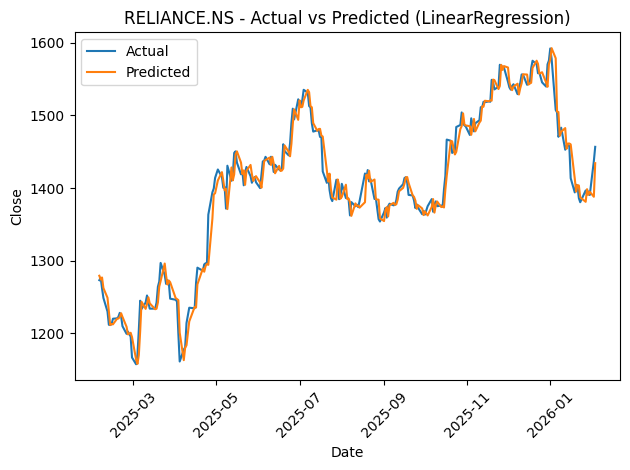

In [ ]:
import matplotlib.pyplot as plt
best_name = results_df.iloc[0]['Model']
print('Best model:', best_name)
yhat_best = yhat_test_dict[best_name]

plt.figure()
plt.plot(work_test['date'].values, y_test, label='Actual')
plt.plot(work_test['date'].values, yhat_best, label='Predicted')
plt.legend()
plt.title(f'{TICKER} - Actual vs Predicted ({best_name})')
plt.xlabel('Date')
plt.ylabel(PREDICT_TARGET)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 🔮 Next-day prediction from latest features

In [ ]:
best_model = models[best_name]
latest_row = work.iloc[-1][feature_cols].values.reshape(1,-1)
pred_next = best_model.predict(latest_row)[0]
last_date = work.iloc[-1]['date']
last_close = work.iloc[-1]['close']
if PREDICT_TARGET == 'Close':
    print(f'Last date: {last_date.date()} | Last close: {last_close:.2f}')
    print(f'Predicted next close: {pred_next:.2f}')
else:
    print(f'Last date: {last_date.date()} | Last close: {last_close:.2f}')
    print(f'Predicted next-day return: {pred_next*100:.2f}%')


Last date: 2026-02-03 | Last close: 1437.10
Predicted next close: 1434.32


## 💾 Save artifacts (results table & predictions)

In [ ]:
import os
import time
out_dir = 'outputs'
os.makedirs(out_dir, exist_ok=True)
csv_path = os.path.join(out_dir, f'{TICKER}_results_{int(time.time())}.csv')
results_df.to_csv(csv_path, index=False)
print('Saved metrics to:', csv_path)


Saved metrics to: outputs/RELIANCE.NS_results_1770286343.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os, time

drive_dir = '/content/drive/MyDrive/StockProjectOutputs'
os.makedirs(drive_dir, exist_ok=True)

csv_path = os.path.join(drive_dir, f'{TICKER}_results_{int(time.time())}.csv')
results_df.to_csv(csv_path, index=False)

print("Saved file to:", csv_path)


Saved file to: /content/drive/MyDrive/StockProjectOutputs/RELIANCE.NS_results_1770286376.csv


In [ ]:
plot_path = '/content/drive/MyDrive/StockProjectOutputs/prediction_plot.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

print("Plot saved to:", plot_path)


Plot saved to: /content/drive/MyDrive/StockProjectOutputs/prediction_plot.png


<Figure size 640x480 with 0 Axes>

In [ ]:
df_path = '/content/drive/MyDrive/StockProjectOutputs/final_dataset.csv'
df.to_csv(df_path, index=False)
print("Final dataset saved to:", df_path)


Final dataset saved to: /content/drive/MyDrive/StockProjectOutputs/final_dataset.csv


In [ ]:
pred_df = work_test.copy()
pred_df['predicted'] = yhat_best

pred_path = '/content/drive/MyDrive/StockProjectOutputs/predictions.csv'
pred_df.to_csv(pred_path, index=False)

print("Predictions saved to:", pred_path)


Predictions saved to: /content/drive/MyDrive/StockProjectOutputs/predictions.csv


## 📝 Notes & Extensions
- Try other indicators (OBV, Stochastic, ATR).
- Add *lagged* features (e.g., RSI_14 lagged by 1–3 days).
- Switch to a *rolling* origin validation for more robust backtests.
- If `yfinance` news is empty, you can prepare a CSV with two columns: `date,title` and load it, then compute VADER scores per day and merge like above.


In [ ]:
input_cols = [
    'date','open','high','low','close','volume',
    'return_1d','volatility_20',
    'sma_10','sma_50','ema_20',
    'rsi_14','macd','macd_signal',
    'bb_high','bb_low','sentiment_daily'
]
df[input_cols].tail(10)


,date,open,high,low,close,volume,return_1d,volatility_20,sma_10,sma_50,ema_20,rsi_14,macd,macd_signal,bb_high,bb_low,sentiment_daily
1990,2026-01-21,1389.500000,1412.900024,1373.000000,1404.599976,17352720,0.007604,0.015051,1446.960010,1526.146003,1479.581161,27.785517,-33.870326,-21.043935,1620.756973,1379.303025,0.0
1991,2026-01-22,1410.099976,1419.500000,1395.000000,1402.500000,15721693,-0.001495,0.015064,1440.150012,1523.966003,1472.240098,27.488121,-35.610169,-23.957181,1616.977711,1367.512291,0.0
1992,2026-01-23,1401.800049,1407.000000,1381.000000,1386.099976,9837802,-0.011693,0.015068,1431.230005,1521.470002,1464.036277,25.218031,-37.875744,-26.740894,1612.490635,1354.689370,0.0
1993,2026-01-27,1380.000000,1391.599976,1368.000000,1380.500000,26302396,-0.004040,0.015055,1420.960010,1518.702002,1456.080441,24.474768,-39.665857,-29.325887,1608.373553,1342.296455,0.0
1994,2026-01-28,1385.000000,1409.900024,1384.900024,1396.699951,11121657,0.011735,0.015542,1415.350000,1516.270000,1450.425156,30.826386,-39.324030,-31.325515,1601.970974,1334.389024,0.0
1995,2026-01-29,1402.900024,1402.900024,1384.000000,1391.000000,20846683,-0.004081,0.014428,1408.569995,1513.702000,1444.765617,29.874394,-39.062777,-32.872968,1588.360085,1330.059910,0.0
1996,2026-01-30,1382.599976,1398.000000,1378.500000,1395.400024,11239835,0.003163,0.014423,1402.229993,1511.232000,1440.064132,31.629677,-38.061933,-33.910761,1570.449915,1329.950085,0.0
1997,2026-02-02,1340.000000,1392.900024,1335.500000,1390.400024,15711165,-0.003583,0.013905,1395.479993,1508.058000,1435.334217,30.689604,-37.242902,-34.577189,1543.686505,1336.523493,0.0
1998,2026-02-03,1473.900024,1489.500000,1430.199951,1437.099976,25456171,0.033587,0.016541,1397.829993,1505.868000,1435.502385,46.641192,-32.451438,-34.152039,1515.052570,1351.057427,0.0
1999,2026-02-04,1444.000000,1464.000000,1440.300049,1456.800049,8333387,0.013708,0.014049,1404.109998,1504.286001,1437.530734,51.691999,-26.756109,-32.672853,1506.007851,1355.022154,0.0


In [ ]:
output_df = work_test.copy()
output_df['predicted'] = yhat_best
output_df[['date','close','predicted']].tail(10)


,date,close,predicted
1989,2026-01-20,1394.000000,1395.133414
1990,2026-01-21,1404.599976,1404.128753
1991,2026-01-22,1402.500000,1403.516939
1992,2026-01-23,1386.099976,1387.173432
1993,2026-01-27,1380.500000,1381.056656
1994,2026-01-28,1396.699951,1398.500283
1995,2026-01-29,1391.000000,1390.637980
1996,2026-01-30,1395.400024,1394.914097
1997,2026-02-02,1390.400024,1388.019692
1998,2026-02-03,1437.099976,1434.319174


In [ ]:
print("Last available date:", last_date.date())
print("Last closing price:", last_close)
print("Predicted next closing price:", pred_next)


Last available date: 2026-02-03
Last closing price: 1437.0999755859375
Predicted next closing price: 1434.319174264066


In [ ]:
last_row = work.iloc[-1][input_cols]
print("Model Input for Last Day:")
display(pd.DataFrame([last_row]))

print("\nModel Output (Next Day Prediction):")
print("Predicted Next Close:", pred_next)


Model Input for Last Day:


,date,open,high,low,close,volume,return_1d,volatility_20,sma_10,sma_50,ema_20,rsi_14,macd,macd_signal,bb_high,bb_low,sentiment_daily
1998,2026-02-03,1473.900024,1489.5,1430.199951,1437.099976,25456171,0.033587,0.016541,1397.829993,1505.868,1435.502385,46.641192,-32.451438,-34.152039,1515.05257,1351.057427,0.0



Model Output (Next Day Prediction):
Predicted Next Close: 1434.319174264066


# ✅ How to SEE Your Inputs & Outputs **Clearly**

In [ ]:
print("=== PROJECT INPUTS ===")
print("Ticker:", TICKER)
print("Date Range:", START, "to", END)
print("\nFirst 5 rows of raw downloaded data:\n")
display(df.head())

print("\nColumns in dataset:")
print(list(df.columns))


=== PROJECT INPUTS ===
Ticker: RELIANCE.NS
Date Range: 2018-01-01 to 2026-02-05

First 5 rows of raw downloaded data:



,date,close,high,low,open,volume,return_1d,volatility_20,sma_10,sma_50,ema_20,rsi_14,macd,macd_signal,bb_high,bb_low,close_tomorrow,return_1d_ahead,sentiment_daily
0,2018-01-01,401.864838,407.585239,400.870942,407.585239,9453202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,402.483215,0.001539,0.0
1,2018-01-02,402.483215,406.193768,400.384994,403.300424,9499419,0.001539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,404.095581,0.004006,0.0
2,2018-01-03,404.095581,409.042975,403.322544,408.601227,13507800,0.004006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,406.525085,0.006012,0.0
3,2018-01-04,406.525085,407.187693,404.493122,405.575361,9008932,0.006012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,407.828217,0.003206,0.0
4,2018-01-05,407.828217,409.440548,406.503032,407.187725,7441284,0.003206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,410.169342,0.005740,0.0



Columns in dataset:
['date', 'close', 'high', 'low', 'open', 'volume', 'return_1d', 'volatility_20', 'sma_10', 'sma_50', 'ema_20', 'rsi_14', 'macd', 'macd_signal', 'bb_high', 'bb_low', 'close_tomorrow', 'return_1d_ahead', 'sentiment_daily']


In [ ]:
print("=== PROJECT OUTPUTS ===")
print("\n1. Technical Indicators + Sentiment Added:")
display(df.tail())
print("\n2. Train/Test Shapes:")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\n3. Model Evaluation Table:")
display(results_df)
print("\n4. Next-Day Prediction:")
print(pred_next)

=== PROJECT OUTPUTS ===

1. Technical Indicators + Sentiment Added:


,date,close,high,low,open,volume,return_1d,volatility_20,sma_10,sma_50,ema_20,rsi_14,macd,macd_signal,bb_high,bb_low,close_tomorrow,return_1d_ahead,sentiment_daily
1995,2026-01-29,1391.000000,1402.900024,1384.000000,1402.900024,20846683,-0.004081,0.014428,1408.569995,1513.702000,1444.765617,29.874394,-39.062777,-32.872968,1588.360085,1330.059910,1395.400024,0.003163,0.0
1996,2026-01-30,1395.400024,1398.000000,1378.500000,1382.599976,11239835,0.003163,0.014423,1402.229993,1511.232000,1440.064132,31.629677,-38.061933,-33.910761,1570.449915,1329.950085,1390.400024,-0.003583,0.0
1997,2026-02-02,1390.400024,1392.900024,1335.500000,1340.000000,15711165,-0.003583,0.013905,1395.479993,1508.058000,1435.334217,30.689604,-37.242902,-34.577189,1543.686505,1336.523493,1437.099976,0.033587,0.0
1998,2026-02-03,1437.099976,1489.500000,1430.199951,1473.900024,25456171,0.033587,0.016541,1397.829993,1505.868000,1435.502385,46.641192,-32.451438,-34.152039,1515.052570,1351.057427,1456.800049,0.013708,0.0
1999,2026-02-04,1456.800049,1464.000000,1440.300049,1444.000000,8333387,0.013708,0.014049,1404.109998,1504.286001,1437.530734,51.691999,-26.756109,-32.672853,1506.007851,1355.022154,NaN,NaN,0.0



2. Train/Test Shapes:
Train shape: (1703, 16)
Test shape: (247, 16)

3. Model Evaluation Table:


,Model,MAE,RMSE,MAPE_%,R2
0,LinearRegression,12.345716,17.273711,0.886619,0.972929
1,RandomForest,16.230390,21.073387,1.156980,0.959710
2,XGBoost,18.353609,23.458470,1.296810,0.950074
3,SVR_RBF,301.788469,324.297989,21.114757,-8.541463



4. Next-Day Prediction:
1434.319174264066


In [ ]:
df[['date','close','sma_10','ema_20','rsi_14','sentiment_daily']].head()


,date,close,sma_10,ema_20,rsi_14,sentiment_daily
0,2018-01-01,401.864838,NaN,NaN,NaN,0.0
1,2018-01-02,402.483215,NaN,NaN,NaN,0.0
2,2018-01-03,404.095581,NaN,NaN,NaN,0.0
3,2018-01-04,406.525085,NaN,NaN,NaN,0.0
4,2018-01-05,407.828217,NaN,NaN,NaN,0.0


In [ ]:
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (1703, 16) Test shape: (247, 16)


In [ ]:
y_test = pd.Series(y_test)
print("Last Close:", y_test.iloc[-1])
print("Predicted Next Close:", yhat_best[-1])


Last Close: 1456.800048828125
Predicted Next Close: 1434.3191742640656
